In [263]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torchvision
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm

In [264]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [265]:
# Params
batch_size = 32
IMAGES_COUNT = 10
learning_rate = 1e-8
num_epochs = 7
image_size = 64
channels = 1
latent_dim = 64
num_embeddings = 128  # Number of vectors in the codebook
commitment_cost = 0.2  # Beta, the commitment loss weight

In [266]:
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

In [267]:
def show_image(batch_of_tensors):
    images = batch_of_tensors[:4]

    # denormalize if Normalize((0.5,), (0.5,)) was used
    # images = images * 0.5 + 0.5

    print(f"Plotting image shape: {str(images[0].shape)}")
    
    grid_img = torchvision.utils.make_grid(images, nrow=2)

    plt.figure(figsize=(2, 2))
    plt.imshow(grid_img.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.axis('off')
    plt.show()

In [268]:
class VQEmbedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings

        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1/self.num_embeddings, 1/self.num_embeddings)

    def forward(self, z):
        b, c, h, w = z.shape
        z_channel_last = z.permute(0, 2, 3, 1)
        z_flattened = z_channel_last.reshape(b*h*w, self.embedding_dim)

        # Calculate distances between z and the codebook embeddings |a-b|²
        # Euclidean distance. Form applied for efficiency in deep learning. In literature l2 distance is used.
        distances = (
            torch.sum(z_flattened ** 2, dim=-1, keepdim=True)                 # a²
            + torch.sum(self.embedding.weight.t() ** 2, dim=0, keepdim=True)  # b²
            - 2 * torch.matmul(z_flattened, self.embedding.weight.t())        # -2ab
        )

        # Get the index with the smallest distance
        # Finds minimum indexes at each row. Uses nearest neigboor look up
        encoding_indices = torch.argmin(distances, dim=-1)

        # Get the quantized vector
        z_q = self.embedding(encoding_indices)
        # when we find the indexes feature vectors, we reshape them to the encoder latent 
        # representation shape
        z_q = z_q.reshape(b, h, w, self.embedding_dim)
        
        # changed the order of the reshaped z_q
        z_q = z_q.permute(0, 3, 1, 2)

        # Calculate the commitment loss
        # Measures how closely the encoder outputs and the selected codebook embeddings match each other.
        loss = F.mse_loss(z_q, z.detach()) + commitment_cost * F.mse_loss(z_q.detach(), z)

        # Straight-through estimator trick for gradient backpropagation
        # Finding closer membership to indexes
        z_q = z + (z_q - z).detach()

        return z_q, loss, encoding_indices

In [269]:
class VQVAE(nn.Module):
    def __init__(self):
        super(VQVAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, 8, kernel_size=4, stride=2, padding=3),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=4, stride=2, padding=3),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=3),
            nn.ReLU(),
            nn.Conv2d(32, latent_dim, kernel_size=1)
        )

        # Vector Quantization
        self.vq_layer = VQEmbedding(num_embeddings, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 64, kernel_size=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=3),
            nn.ReLU(),
            # switches in channels and out channels. (in_channels, out_channels, kH, kW)
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=3),
            nn.ReLU(),
            nn.ConvTranspose2d(16, channels, kernel_size=4, stride=2, padding=3),
            # nn.Tanh()  # Output values in range [-1, 1]
        )

    def forward(self, x):
        z_e = self.encoder(x)
        z_q, vq_loss, _ = self.vq_layer(z_e)
        x_recon = self.decoder(z_q)
        return x_recon, vq_loss

In [270]:
model = VQVAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [271]:
def _get_vq_loss(recon_x, x, vq_loss):
    recon_loss = F.mse_loss(recon_x, x)
    return recon_loss + vq_loss

In [272]:
# Training Loop
reconstructed_images = []

# initial images before reconstruction
images_org = []

# loss
loss_values = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    # Use tqdm for the progress bar
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f'Epoch {epoch+1}/{num_epochs}')

    for batch_idx, (data, _) in pbar:
        data = data.to(device)
        images_org.append(data)

        optimizer.zero_grad()
        recon_batch, vq_loss = model(data)
        reconstructed_images.append(recon_batch)
        
        loss = _get_vq_loss(recon_batch, data, vq_loss)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
        loss_values.append(vq_loss.cpu().detach().numpy())

        # Update tqdm description with current loss
        pbar.set_postfix({'Loss': loss.item()})

    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')

    # Save and display a sample of the reconstructed images
    # if (epoch + 1) % 10 == 0:
    #     with torch.no_grad():
    #         recon_batch, _ = model(data)
    #         show_image(data.cpu())
    #         show_image(recon_batch.cpu())

Epoch 1/7: 100%|██████████| 1875/1875 [00:11<00:00, 160.85it/s, Loss=0.116] 


Epoch [1/7] Average Loss: 0.0035


Epoch 2/7: 100%|██████████| 1875/1875 [00:11<00:00, 165.89it/s, Loss=0.116] 


Epoch [2/7] Average Loss: 0.0035


Epoch 3/7: 100%|██████████| 1875/1875 [00:11<00:00, 167.91it/s, Loss=0.116] 


...

Epoch [5/7] Average Loss: 0.0035


Epoch 6/7: 100%|██████████| 1875/1875 [00:11<00:00, 163.00it/s, Loss=0.114] 


Epoch [6/7] Average Loss: 0.0035


Epoch 7/7: 100%|██████████| 1875/1875 [00:11<00:00, 164.73it/s, Loss=0.113]

Epoch [7/7] Average Loss: 0.0035


Displaying images (Before/After reconstruction)
Plotting image shape: torch.Size([1, 28, 28])


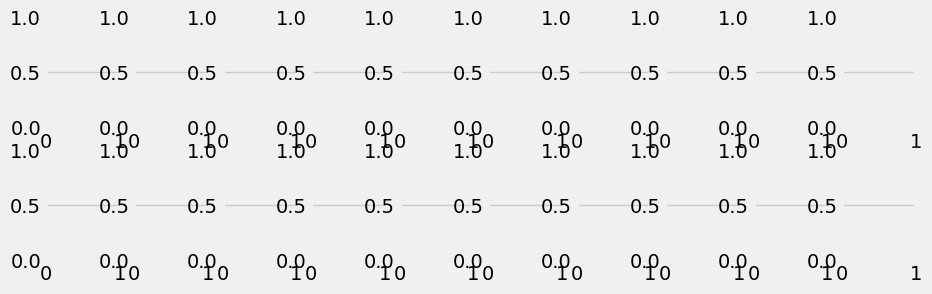

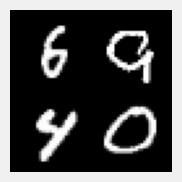

Plotting image shape: torch.Size([1, 28, 28])


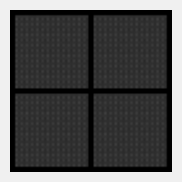

Plotting image shape: torch.Size([1, 28, 28])


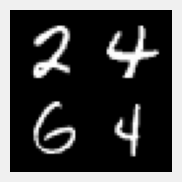

Plotting image shape: torch.Size([1, 28, 28])


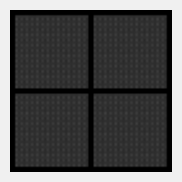

Plotting image shape: torch.Size([1, 28, 28])


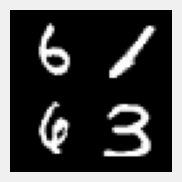

Plotting image shape: torch.Size([1, 28, 28])


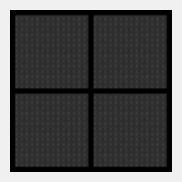

Plotting image shape: torch.Size([1, 28, 28])


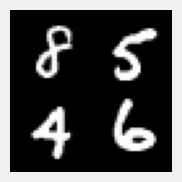

Plotting image shape: torch.Size([1, 28, 28])


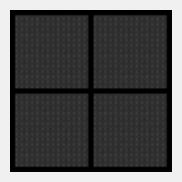

Plotting image shape: torch.Size([1, 28, 28])


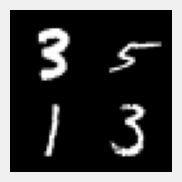

Plotting image shape: torch.Size([1, 28, 28])


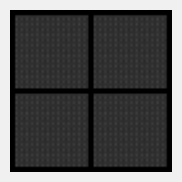

Plotting image shape: torch.Size([1, 28, 28])


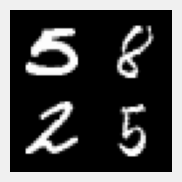

Plotting image shape: torch.Size([1, 28, 28])


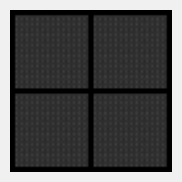

Plotting image shape: torch.Size([1, 28, 28])


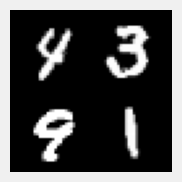

Plotting image shape: torch.Size([1, 28, 28])


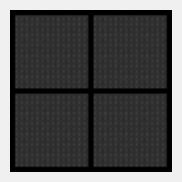

In [273]:
print("Displaying images (Before/After reconstruction)")
fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(10, 3))
for i in range(num_epochs):
    show_image(images_org[i].cpu())
    show_image(reconstructed_images[i].cpu())

Printing loss


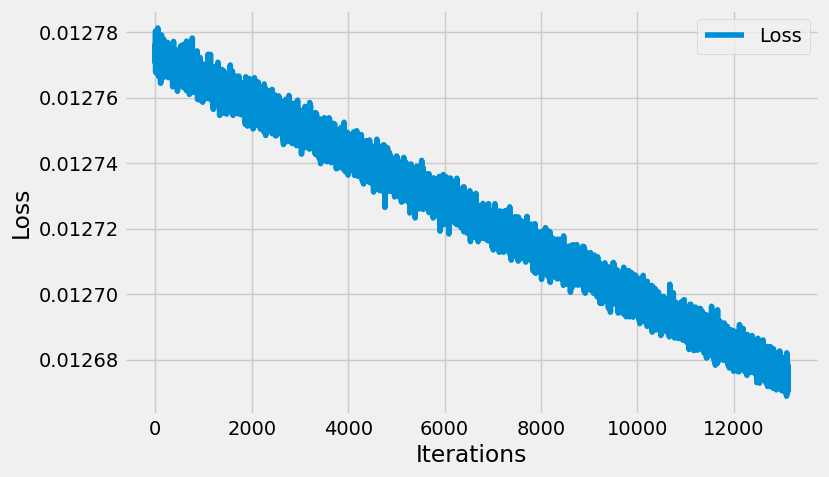

In [274]:
print("Printing loss")
plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(loss_values, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()